## Setup imports + paths

In [1]:
# ============================================
# Cell 1 — Setup: imports, paths, class registry
# ============================================
import os, sys, time, json, random, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import trimesh

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

REPO_ROOT = Path('/Users/dosvatsky/3D Object Detection')
MESH_ROOT = REPO_ROOT / 'data' / 'mesh_dataset_v1'
SCENE_OUT = REPO_ROOT / 'data' / 'synthetic_scenes_v1'
SCENE_OUT.mkdir(parents=True, exist_ok=True)

# 27 classes in fixed order — this order MUST match later VoteNet config
# Furniture first (matches our SUN RGB-D class order for backbone compatibility)
FURNITURE_CLASSES = [
    'bed', 'table', 'sofa', 'chair', 'toilet',
    'desk', 'dresser', 'night_stand', 'bookshelf', 'bathtub',
]
# Military classes second
MILITARY_CLASSES = [
    'ammo_box', 'binoculars', 'combat_knife', 'flashlight',
    'gas_mask', 'hand_grenade', 'helmet', 'magazine',
    'military_radio', 'pistol', 'rifle', 'rocket_launcher',
    'shotgun', 'sniper_rifle', 'tactical_backpack',
    'tactical_vest', 'wire_cutter',
]
CLASS_NAMES = FURNITURE_CLASSES + MILITARY_CLASSES  # 10 + 17 = 27
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

# Real-world dimensions per class (meters) — used to scale meshes uniformly
# These are typical longest-axis lengths; meshes get scaled to match
CLASS_REAL_SIZE = {
    # Furniture
    'bed':            2.0,
    'table':          1.5,
    'sofa':           2.0,
    'chair':          0.85,
    'toilet':         0.70,
    'desk':           1.4,
    'dresser':        1.2,
    'night_stand':    0.55,
    'bookshelf':      1.5,
    'bathtub':        1.7,
    # Military
    'ammo_box':       0.35,
    'binoculars':     0.18,
    'combat_knife':   0.30,
    'flashlight':     0.20,
    'gas_mask':       0.28,
    'hand_grenade':   0.11,
    'helmet':         0.28,
    'magazine':       0.15,
    'military_radio': 0.22,
    'pistol':         0.22,
    'rifle':          0.95,
    'rocket_launcher':1.10,
    'shotgun':        1.00,
    'sniper_rifle':   1.20,
    'tactical_backpack': 0.55,
    'tactical_vest':  0.50,
    'wire_cutter':    0.22,
}

assert set(CLASS_REAL_SIZE.keys()) == set(CLASS_NAMES), 'Class lists must match'

print(f'Repo:       {REPO_ROOT}')
print(f'Mesh data:  {MESH_ROOT}')
print(f'Scene out:  {SCENE_OUT}')
print(f'\n{NUM_CLASSES} classes registered:')
for i, n in enumerate(CLASS_NAMES):
    cat = 'FURN' if n in FURNITURE_CLASSES else 'MIL '
    print(f'  {i:2d} [{cat}] {n:22s} target size {CLASS_REAL_SIZE[n]:.2f}m')

# Confirm Python can find trimesh
print(f'\ntrimesh version: {trimesh.__version__}')

Repo:       /Users/dosvatsky/3D Object Detection
Mesh data:  /Users/dosvatsky/3D Object Detection/data/mesh_dataset_v1
Scene out:  /Users/dosvatsky/3D Object Detection/data/synthetic_scenes_v1

27 classes registered:
   0 [FURN] bed                    target size 2.00m
   1 [FURN] table                  target size 1.50m
   2 [FURN] sofa                   target size 2.00m
   3 [FURN] chair                  target size 0.85m
   4 [FURN] toilet                 target size 0.70m
   5 [FURN] desk                   target size 1.40m
   6 [FURN] dresser                target size 1.20m
   7 [FURN] night_stand            target size 0.55m
   8 [FURN] bookshelf              target size 1.50m
   9 [FURN] bathtub                target size 1.70m
  10 [MIL ] ammo_box               target size 0.35m
  11 [MIL ] binoculars             target size 0.18m
  12 [MIL ] combat_knife           target size 0.30m
  13 [MIL ] flashlight             target size 0.20m
  14 [MIL ] gas_mask               target

## Mesh verification and registry build

In [2]:
# ============================================
# Cell 2 — Verify all 277 meshes load + build registry
# ============================================
t0 = time.time()

MESH_REGISTRY = {}   # class_name -> list of mesh file paths
mesh_stats = {'ok': 0, 'failed': [], 'too_small': [], 'too_large': []}

def safe_load_mesh(path):
    """Load mesh, handling Scene-containing .glb files. Returns trimesh.Trimesh or None."""
    try:
        m = trimesh.load(str(path), force='mesh')
        if isinstance(m, trimesh.Scene):
            geoms = list(m.geometry.values())
            if not geoms:
                return None, 'empty scene'
            m = trimesh.util.concatenate(geoms)
        if not isinstance(m, trimesh.Trimesh):
            return None, f'unexpected type {type(m).__name__}'
        if len(m.vertices) < 10:
            return None, f'too few vertices ({len(m.vertices)})'
        return m, None
    except Exception as e:
        return None, str(e)[:100]


print('Verifying meshes (this takes 1-2 min)...\n')

for category, classes in [('furniture', FURNITURE_CLASSES),
                          ('military',  MILITARY_CLASSES)]:
    print(f'=== {category.upper()} ===')
    for class_name in classes:
        class_dir = MESH_ROOT / category / class_name
        if not class_dir.exists():
            print(f'  {class_name:22s} DIR MISSING: {class_dir}')
            MESH_REGISTRY[class_name] = []
            continue

        mesh_paths = sorted(list(class_dir.glob('*.glb')) +
                            list(class_dir.glob('*.GLB')) +
                            list(class_dir.glob('*.off')))

        valid = []
        for mp in mesh_paths:
            mesh, err = safe_load_mesh(mp)
            if mesh is None:
                mesh_stats['failed'].append((str(mp), err))
                continue
            n_v = len(mesh.vertices)
            if n_v > 500_000:
                mesh_stats['too_large'].append((str(mp), n_v))
                # Still add it — we'll decimate during loading later
            valid.append(str(mp))
            mesh_stats['ok'] += 1

        MESH_REGISTRY[class_name] = valid
        status = '✅' if len(valid) >= 5 else '⚠️ '
        print(f'  {status} {class_name:22s} {len(valid):3d}/{len(mesh_paths):3d} valid')

elapsed = time.time() - t0
print(f'\n=== SUMMARY ({elapsed:.0f}s) ===')
print(f'  Total valid meshes: {mesh_stats["ok"]}')
print(f'  Failed loads:       {len(mesh_stats["failed"])}')
print(f'  Too-large (>500k):  {len(mesh_stats["too_large"])}')

if mesh_stats['failed']:
    print(f'\nFAILED meshes (first 10):')
    for p, e in mesh_stats['failed'][:10]:
        print(f'  {Path(p).name}: {e}')

if mesh_stats['too_large']:
    print(f'\nTOO LARGE — will be auto-decimated:')
    for p, n in mesh_stats['too_large'][:10]:
        print(f'  {Path(p).name}: {n} vertices')

# Confirm coverage
classes_with_too_few = [n for n in CLASS_NAMES if len(MESH_REGISTRY.get(n, [])) < 5]
if classes_with_too_few:
    print(f'\n⚠️  Classes with <5 valid meshes (need attention):')
    for n in classes_with_too_few:
        print(f'  {n}: {len(MESH_REGISTRY.get(n, []))}')
else:
    print(f'\n✅ All 27 classes have ≥5 valid meshes. Registry ready.')

Verifying meshes (this takes 1-2 min)...

=== FURNITURE ===
  ✅ bed                     10/ 10 valid
  ✅ table                   10/ 10 valid
  ✅ sofa                    10/ 10 valid
  ✅ chair                   10/ 10 valid
  ✅ toilet                  10/ 10 valid
  ✅ desk                    10/ 10 valid
  ✅ dresser                 10/ 10 valid
  ✅ night_stand             10/ 10 valid
  ✅ bookshelf               10/ 10 valid
  ✅ bathtub                 10/ 10 valid
=== MILITARY ===
  ✅ ammo_box                10/ 10 valid
  ✅ binoculars              10/ 10 valid
  ✅ combat_knife            10/ 10 valid
  ✅ flashlight              10/ 10 valid
  ✅ gas_mask                10/ 10 valid
  ✅ hand_grenade            10/ 10 valid
  ✅ helmet                  10/ 10 valid
  ✅ magazine                10/ 10 valid
  ✅ military_radio          17/ 17 valid
  ✅ pistol                  10/ 10 valid
  ✅ rifle                   10/ 10 valid
  ✅ rocket_launcher         10/ 10 valid
  ✅ shotgun          

## Helper Functions for Scene Generation

In [4]:
# ============================================
# Cell 3 — Scene generator functions
# ============================================
import trimesh
import numpy as np

# Cache for normalized meshes (so we don't reload + re-normalize on every scene)
MESH_CACHE = {}

def load_normalized_mesh(path, class_name, decimate_threshold=200_000):
    """Load mesh, decimate if too large, scale to class real-world size, place min-Y at 0."""
    cache_key = (path, class_name)
    if cache_key in MESH_CACHE:
        return MESH_CACHE[cache_key].copy()

    m = trimesh.load(str(path), force='mesh')
    if isinstance(m, trimesh.Scene):
        geoms = list(m.geometry.values())
        m = trimesh.util.concatenate(geoms)

    # Decimate if too high-poly (huge meshes slow down sampling)
    if len(m.vertices) > decimate_threshold:
        try:
            target_faces = decimate_threshold // 2
            m = m.simplify_quadric_decimation(target_faces)
        except Exception:
            pass  # decimation failures are rare but not fatal

    # 1. Center XZ at origin (we'll translate after rotation)
    centroid = m.centroid.copy()
    m.apply_translation(-centroid)

    # 2. Scale uniformly so longest extent = target real-world size
    target_size = CLASS_REAL_SIZE[class_name]
    longest_extent = float(m.extents.max())
    if longest_extent > 1e-6:
        m.apply_scale(target_size / longest_extent)

    # 3. Translate so min Y = 0 (object sits on floor)
    min_y = float(m.bounds[0, 1])
    m.apply_translation([0, -min_y, 0])

    MESH_CACHE[cache_key] = m.copy()
    return m.copy()


def aabb_overlap_2d(a, b, buffer=0.05):
    """Check 2D AABB overlap in XZ plane. Bboxes are (xmin, zmin, xmax, zmax)."""
    if a[2] + buffer < b[0] or b[2] + buffer < a[0]:
        return False
    if a[3] + buffer < b[1] or b[3] + buffer < a[1]:
        return False
    return True


def sample_room_background(room_x, room_y, room_z,
                           n_floor=2500, n_walls=2000, n_ceiling=500):
    """Sample background points from floor (Y=0), 4 walls, and ceiling."""
    pts = []
    # Floor
    pts.append(np.column_stack([
        np.random.uniform(0, room_x, n_floor),
        np.zeros(n_floor),
        np.random.uniform(0, room_z, n_floor),
    ]))
    # 4 walls
    n_per_wall = n_walls // 4
    # x=0 wall
    pts.append(np.column_stack([
        np.zeros(n_per_wall),
        np.random.uniform(0, room_y, n_per_wall),
        np.random.uniform(0, room_z, n_per_wall),
    ]))
    # x=room_x wall
    pts.append(np.column_stack([
        np.full(n_per_wall, room_x),
        np.random.uniform(0, room_y, n_per_wall),
        np.random.uniform(0, room_z, n_per_wall),
    ]))
    # z=0 wall
    pts.append(np.column_stack([
        np.random.uniform(0, room_x, n_per_wall),
        np.random.uniform(0, room_y, n_per_wall),
        np.zeros(n_per_wall),
    ]))
    # z=room_z wall
    pts.append(np.column_stack([
        np.random.uniform(0, room_x, n_per_wall),
        np.random.uniform(0, room_y, n_per_wall),
        np.full(n_per_wall, room_z),
    ]))
    # Ceiling
    pts.append(np.column_stack([
        np.random.uniform(0, room_x, n_ceiling),
        np.full(n_ceiling, room_y),
        np.random.uniform(0, room_z, n_ceiling),
    ]))
    return np.concatenate(pts).astype(np.float32)


def generate_scene(n_objects_range=(6, 12),
                   output_n_points=20000,
                   max_placement_attempts=20):
    """Generate one synthetic scene with random objects in a random room."""
    # Random room dimensions
    room_x = random.uniform(4.0, 6.0)
    room_y = random.uniform(2.5, 3.0)
    room_z = random.uniform(4.0, 6.0)

    n_objects = random.randint(*n_objects_range)
    placed_meshes = []        # list of trimesh objects (placed in world coords)
    placed_classes = []        # list of class name per placed object
    placed_yaws = []           # rotation per object
    placed_bboxes_2d = []      # collision check

    for _ in range(n_objects):
        class_name = random.choice(CLASS_NAMES)
        if not MESH_REGISTRY.get(class_name):
            continue
        mesh_path = random.choice(MESH_REGISTRY[class_name])
        try:
            base_mesh = load_normalized_mesh(mesh_path, class_name)
        except Exception:
            continue

        # Try to place without collision
        for _attempt in range(max_placement_attempts):
            yaw = random.uniform(0, 2 * np.pi)
            mesh_try = base_mesh.copy()
            # Yaw rotation around Y axis
            R = trimesh.transformations.rotation_matrix(yaw, [0, 1, 0])
            mesh_try.apply_transform(R)
            # After rotation, re-center XZ at origin and re-place on floor
            min_y_after = float(mesh_try.bounds[0, 1])
            mesh_try.apply_translation([0, -min_y_after, 0])

            # Find random (x, z) position with margin from walls
            half_x = (mesh_try.bounds[1, 0] - mesh_try.bounds[0, 0]) / 2 + 0.15
            half_z = (mesh_try.bounds[1, 2] - mesh_try.bounds[0, 2]) / 2 + 0.15
            if 2 * half_x > room_x or 2 * half_z > room_z:
                break  # object too large for this room
            cx = random.uniform(half_x, room_x - half_x)
            cz = random.uniform(half_z, room_z - half_z)
            mesh_try.apply_translation([cx, 0, cz])

            # 2D AABB collision check (XZ plane)
            bb2d = (
                float(mesh_try.bounds[0, 0]), float(mesh_try.bounds[0, 2]),
                float(mesh_try.bounds[1, 0]), float(mesh_try.bounds[1, 2])
            )
            if not any(aabb_overlap_2d(bb2d, prev) for prev in placed_bboxes_2d):
                placed_meshes.append(mesh_try)
                placed_classes.append(class_name)
                placed_yaws.append(yaw)
                placed_bboxes_2d.append(bb2d)
                break

    if len(placed_meshes) < 2:
        return None  # too sparse, skip

    # Sample points from each placed object
    object_pts = []
    object_obj_ids = []  # which object each point belongs to (0..N-1)
    object_centers = []
    bboxes = []

    for obj_idx, (mesh, class_name, yaw) in enumerate(zip(placed_meshes, placed_classes, placed_yaws)):
        area = float(mesh.area)
        n_pts = int(np.clip(area * 800, 250, 2000))
        try:
            pts, _ = trimesh.sample.sample_surface(mesh, n_pts)
        except Exception:
            continue
        pts = pts.astype(np.float32)
        center = mesh.bounds.mean(axis=0).astype(np.float32)
        size = mesh.extents.astype(np.float32)

        object_pts.append(pts)
        object_obj_ids.extend([obj_idx] * len(pts))
        object_centers.append(center)
        bboxes.append([
            float(center[0]), float(center[1]), float(center[2]),
            float(size[0]), float(size[1]), float(size[2]),
            float(yaw),
            CLASS_TO_IDX[class_name]
        ])

    if not object_pts:
        return None

    obj_points = np.concatenate(object_pts, axis=0)
    obj_obj_ids = np.array(object_obj_ids, dtype=np.int32)
    bg_points = sample_room_background(room_x, room_y, room_z)
    bg_obj_ids = np.full(len(bg_points), -1, dtype=np.int32)

    all_points = np.concatenate([obj_points, bg_points], axis=0)
    all_obj_ids = np.concatenate([obj_obj_ids, bg_obj_ids])

    # Subsample to output_n_points
    if len(all_points) > output_n_points:
        idx = np.random.choice(len(all_points), output_n_points, replace=False)
        all_points = all_points[idx]
        all_obj_ids = all_obj_ids[idx]
    elif len(all_points) < output_n_points:
        # Pad by repetition
        extra = output_n_points - len(all_points)
        pad_idx = np.random.choice(len(all_points), extra, replace=True)
        all_points = np.concatenate([all_points, all_points[pad_idx]])
        all_obj_ids = np.concatenate([all_obj_ids, all_obj_ids[pad_idx]])

    # Compute votes
    votes = np.zeros((output_n_points, 10), dtype=np.float32)
    fg_mask = all_obj_ids >= 0
    votes[fg_mask, 0] = 1.0  # is_object
    centers_arr = np.array(object_centers, dtype=np.float32)
    fg_indices = np.where(fg_mask)[0]
    for p_idx in fg_indices:
        obj_id = all_obj_ids[p_idx]
        offset = centers_arr[obj_id] - all_points[p_idx]
        votes[p_idx, 1:4] = offset
        votes[p_idx, 4:7] = offset
        votes[p_idx, 7:10] = offset

    # Build (N, 6) point cloud — pad with zeros for color channels (matches VoteNet format)
    pc = np.zeros((output_n_points, 6), dtype=np.float32)
    pc[:, :3] = all_points

    return {
        'pc': pc.astype(np.float32),
        'bbox': np.array(bboxes, dtype=np.float32),
        'votes': votes.astype(np.float32),
        '_room_dims': (room_x, room_y, room_z),
        '_n_objects': len(placed_meshes),
    }


def save_scene(scene, scene_idx, out_dir):
    """Save scene in VoteNet's expected file format."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    base = f'{scene_idx:06d}'
    np.savez(out_dir / f'{base}_pc.npz', pc=scene['pc'])
    np.save(out_dir / f'{base}_bbox.npy', scene['bbox'])
    np.savez(out_dir / f'{base}_votes.npz', point_votes=scene['votes'])


print('Scene generator functions defined.')
print('  load_normalized_mesh()')
print('  aabb_overlap_2d()')
print('  sample_room_background()')
print('  generate_scene()')
print('  save_scene()')

Scene generator functions defined.
  load_normalized_mesh()
  aabb_overlap_2d()
  sample_room_background()
  generate_scene()
  save_scene()


## Generating 5 test scenes and visualizing them

Generating 5 test scenes...

Generated 5 scenes in 8.4s (~1.7s per scene)

Scene 0:
  Room: 5.3m x 2.5m x 4.6m
  Points: 20000 total (13303 fg / 6697 bg)
  Objects: 7 -> toilet, flashlight, bed, night_stand, sofa, night_stand, shotgun

Scene 1:
  Room: 4.3m x 2.7m x 6.0m
  Points: 20000 total (13118 fg / 6882 bg)
  Objects: 11 -> shotgun, table, sofa, dresser, chair, helmet, sniper_rifle, rifle, rifle, hand_grenade, military_radio

Scene 2:
  Room: 5.5m x 2.9m x 4.3m
  Points: 20000 total (12860 fg / 7140 bg)
  Objects: 9 -> magazine, dresser, combat_knife, night_stand, night_stand, night_stand, military_radio, chair, rifle

Scene 3:
  Room: 5.5m x 2.6m x 4.8m
  Points: 20000 total (14403 fg / 5597 bg)
  Objects: 9 -> dresser, combat_knife, shotgun, dresser, table, night_stand, ammo_box, toilet, desk

Scene 4:
  Room: 5.7m x 2.9m x 4.4m
  Points: 20000 total (10217 fg / 9783 bg)
  Objects: 7 -> rocket_launcher, pistol, tactical_vest, ammo_box, bookshelf, ammo_box, rifle

Rendering scen

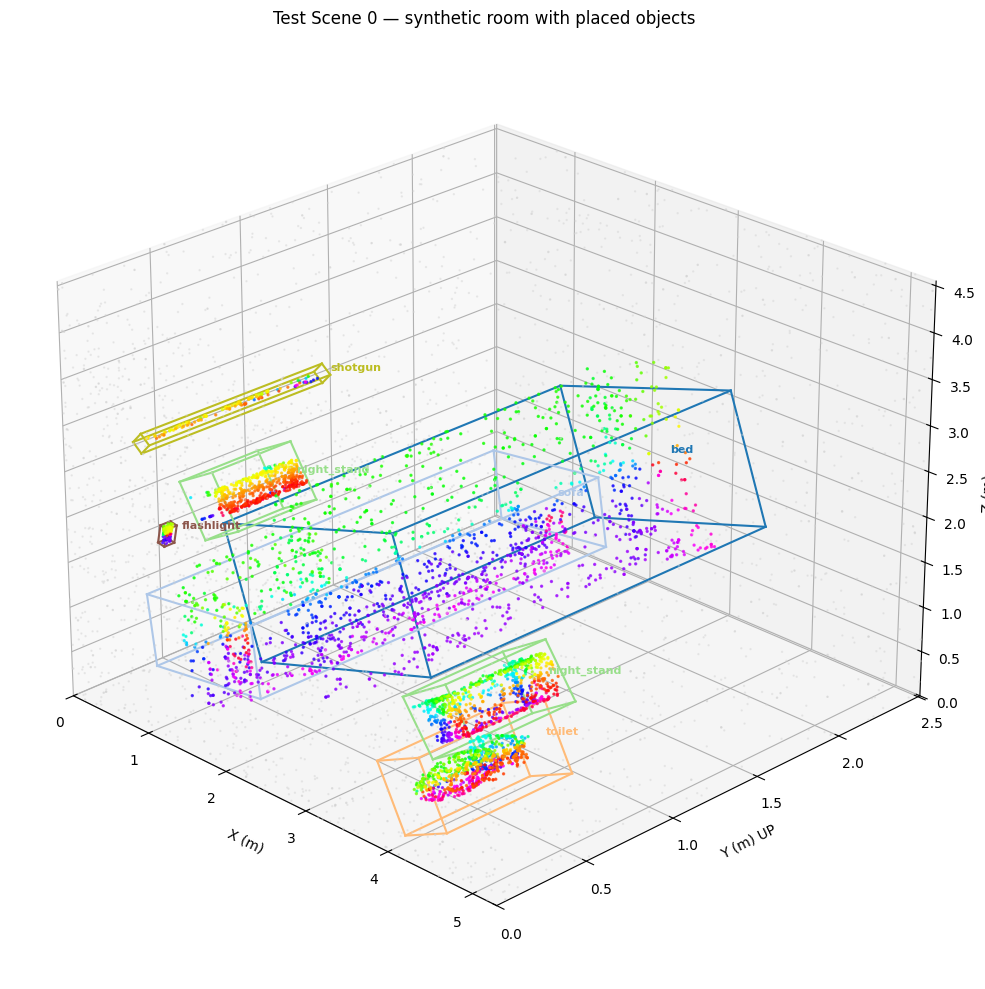

In [5]:
# ============================================
# Cell 4 — Generate 5 test scenes + visualize one
# ============================================
import time
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Box edge connectivity (12 edges of a cube)
BOX_EDGES = [
    (0,1), (1,2), (2,3), (3,0),      # bottom
    (4,5), (5,6), (6,7), (7,4),      # top
    (0,4), (1,5), (2,6), (3,7),      # verticals
]

def compute_box_corners(center, size, heading):
    """8 corners of oriented bbox. Returns (8, 3) array."""
    cx, cy, cz = center
    l, h, w = size
    corners = np.array([
        [-l/2, -h/2, -w/2], [+l/2, -h/2, -w/2],
        [+l/2, +h/2, -w/2], [-l/2, +h/2, -w/2],
        [-l/2, -h/2, +w/2], [+l/2, -h/2, +w/2],
        [+l/2, +h/2, +w/2], [-l/2, +h/2, +w/2],
    ])
    cosh, sinh = np.cos(heading), np.sin(heading)
    R = np.array([[cosh, 0, sinh],
                  [0,    1, 0   ],
                  [-sinh,0, cosh]])
    return corners @ R.T + np.array([cx, cy, cz])


def visualize_scene(scene, title='Test Scene'):
    """Draw point cloud (colored by object) + 3D bounding boxes + class labels."""
    pc = scene['pc'][:, :3]
    bboxes = scene['bbox']
    votes = scene['votes']

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Identify foreground (object) vs background points using votes[:, 0]
    is_fg = votes[:, 0] > 0.5
    bg_pts = pc[~is_fg]
    fg_pts = pc[is_fg]

    # Background as small gray dots
    if len(bg_pts) > 0:
        bg_viz_idx = np.random.choice(len(bg_pts), min(3000, len(bg_pts)), replace=False)
        ax.scatter(bg_pts[bg_viz_idx, 0], bg_pts[bg_viz_idx, 1], bg_pts[bg_viz_idx, 2],
                   c='lightgray', s=0.5, alpha=0.4)

    # Foreground points — colored per object via vote direction
    if len(fg_pts) > 0:
        fg_viz_idx = np.random.choice(len(fg_pts), min(4000, len(fg_pts)), replace=False)
        # Use vote angle as color (just for visual separation between objects)
        votes_fg = votes[is_fg][fg_viz_idx]
        vote_dirs = np.arctan2(votes_fg[:, 3], votes_fg[:, 1])  # vote XZ direction
        ax.scatter(fg_pts[fg_viz_idx, 0], fg_pts[fg_viz_idx, 1], fg_pts[fg_viz_idx, 2],
                   c=vote_dirs, cmap='hsv', s=2, alpha=0.7)

    # Bounding boxes
    colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
    for box in bboxes:
        cx, cy, cz, l, h, w, heading, cls_idx = box
        cls_idx = int(cls_idx)
        corners = compute_box_corners((cx, cy, cz), (l, h, w), heading)
        c = colors[cls_idx]
        for i, j in BOX_EDGES:
            ax.plot3D([corners[i, 0], corners[j, 0]],
                      [corners[i, 1], corners[j, 1]],
                      [corners[i, 2], corners[j, 2]],
                      color=c, linewidth=1.5)
        # Class label at box top
        ax.text(cx, cy + h/2 + 0.05, cz, CLASS_NAMES[cls_idx],
                fontsize=8, color=c, weight='bold')

    room_x, room_y, room_z = scene.get('_room_dims', (5, 3, 5))
    ax.set_xlim(0, room_x); ax.set_ylim(0, room_y); ax.set_zlim(0, room_z)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m) UP'); ax.set_zlabel('Z (m)')
    ax.set_title(title)
    ax.view_init(elev=25, azim=-45)
    plt.tight_layout()
    plt.show()


# === Generate 5 test scenes ===
print('Generating 5 test scenes...\n')
test_scenes = []
t0 = time.time()
attempts = 0
while len(test_scenes) < 5 and attempts < 20:
    attempts += 1
    scene = generate_scene()
    if scene is not None:
        test_scenes.append(scene)

elapsed = time.time() - t0
print(f'Generated {len(test_scenes)} scenes in {elapsed:.1f}s '
      f'(~{elapsed/max(len(test_scenes),1):.1f}s per scene)\n')

# Summary table for each
for i, scene in enumerate(test_scenes):
    bboxes = scene['bbox']
    classes_in_scene = [CLASS_NAMES[int(b[7])] for b in bboxes]
    pc_shape = scene['pc'].shape
    n_fg = int((scene['votes'][:, 0] > 0.5).sum())
    print(f'Scene {i}:')
    print(f'  Room: {scene["_room_dims"][0]:.1f}m x {scene["_room_dims"][1]:.1f}m x {scene["_room_dims"][2]:.1f}m')
    print(f'  Points: {pc_shape[0]} total ({n_fg} fg / {pc_shape[0] - n_fg} bg)')
    print(f'  Objects: {len(bboxes)} -> {", ".join(classes_in_scene)}')
    print()

# === Visualize scene 0 ===
print('Rendering scene 0...')
visualize_scene(test_scenes[0], title='Test Scene 0 — synthetic room with placed objects')